In [53]:
import sys
import torch
sys.path.insert(0, '..')
from train_utils import generate_column_mask, simulate_undersampling, psnr
from DcTNN.dc import fft_2d, ifft_2d, FFT_DC, KSpace_DC

kspace : (36, 640, 372) complex64


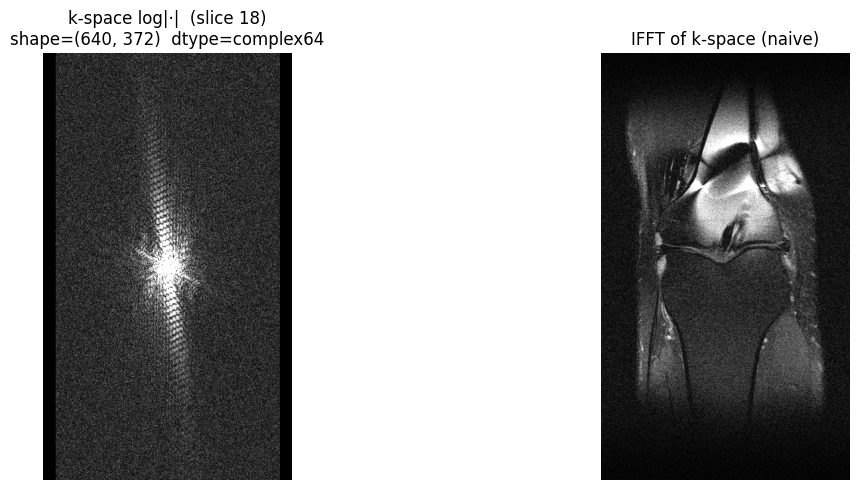

In [77]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

FILE = "../file1000001.h5"

with h5py.File(FILE, "r") as f:
    kspace = f["kspace"][:]               # (36, 640, 372) complex64
    rss    = f["reconstruction_rss"][:]   # (36, 320, 320) float32

print("kspace :", kspace.shape, kspace.dtype)

sl  = kspace.shape[0] // 2
ks  = kspace[sl]   # (640, 372) complex64

naive = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(ks))))

def norm(x, lo=1, hi=99):
    """Clip to percentile range then scale to [0, 1]."""
    a, b = np.percentile(x, lo), np.percentile(x, hi)
    return np.clip((x - a) / (b - a + 1e-8), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(norm(np.abs(ks)), cmap="gray")
axes[0].set_title(f"k-space log|·|  (slice {sl})\nshape={ks.shape}  dtype={ks.dtype}")
axes[0].axis("off")

axes[1].imshow(norm(naive), cmap="gray")
axes[1].set_title("IFFT of k-space (naive)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


/var/folders/5d/795fjfcd50n5hv5kddn8tqb80000gn/T/ipykernel_77308/1528327444.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ks_min_max = minmax_norm(np.abs(ks_sq).numpy())
/var/folders/5d/795fjfcd50n5hv5kddn8tqb80000gn/T/ipykernel_77308/1528327444.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axes[0].imshow(np.log1p(np.abs(ks_sq)), cmap="gray")
/var/folders/5d/795fjfcd50n5hv5kddn8tqb80000gn/T/ipykernel_77308/1528327444.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axes[2].imshow(np.abs(img), cmap="gray")


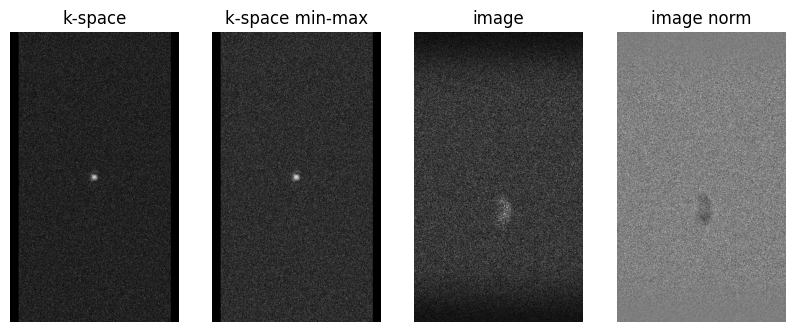

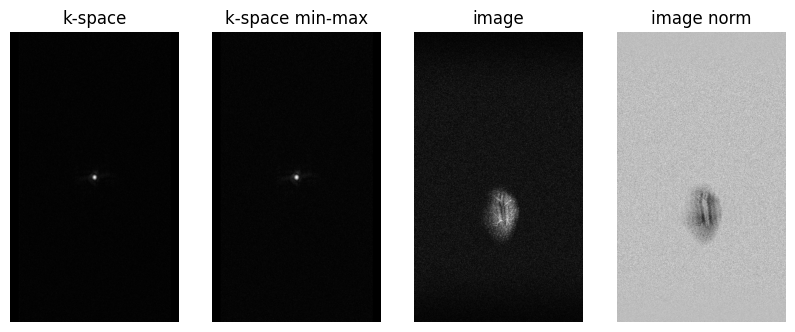

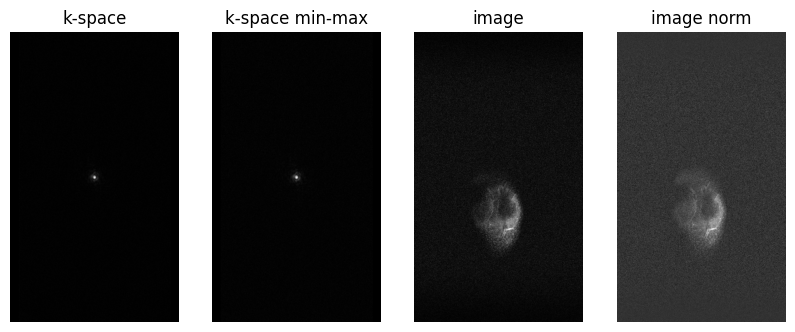

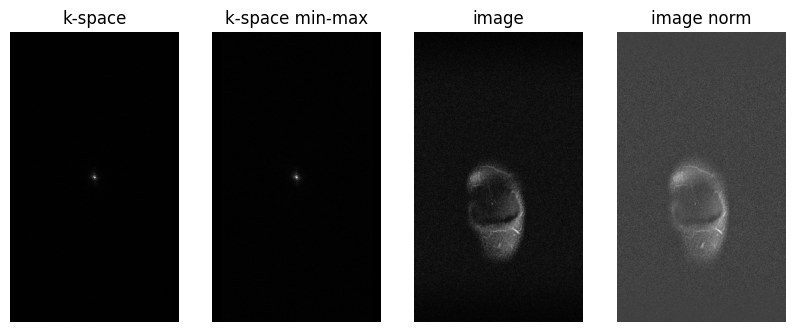

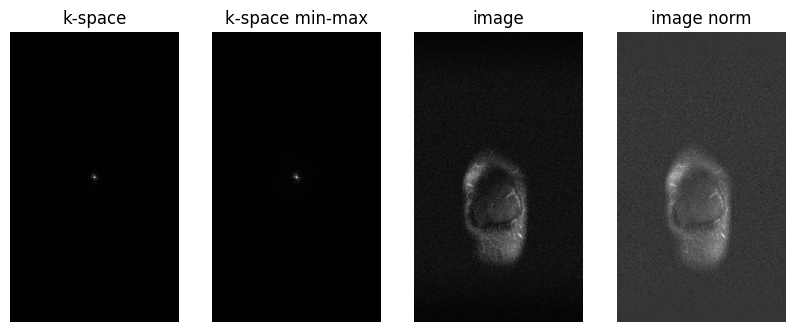

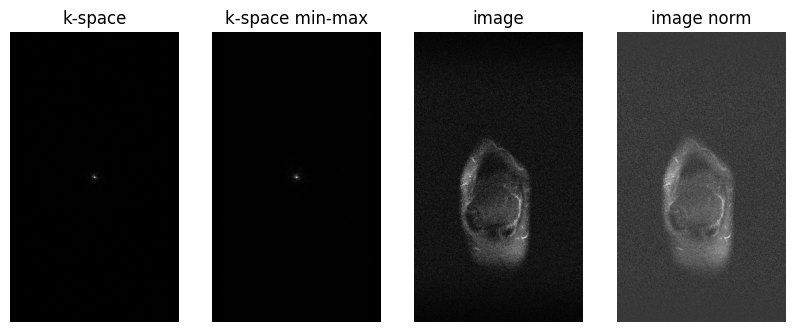

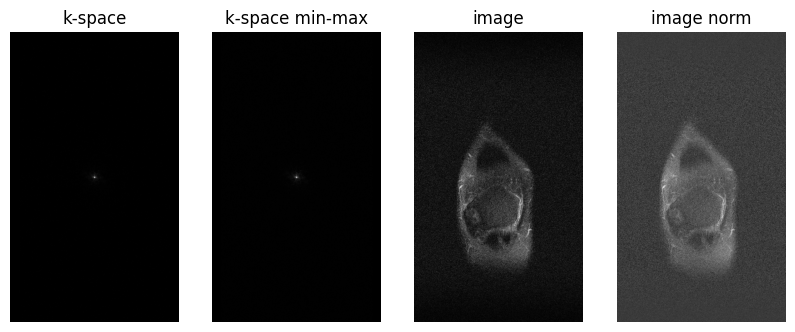

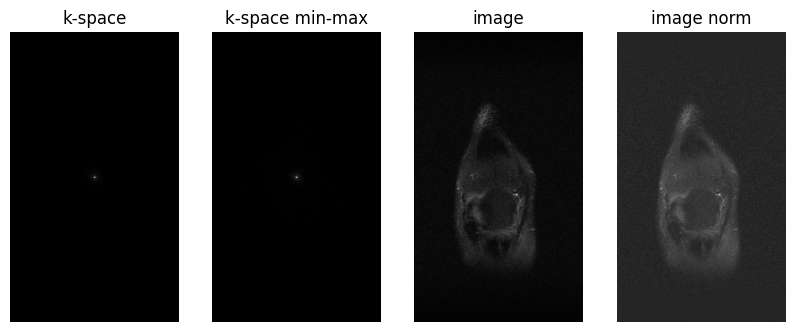

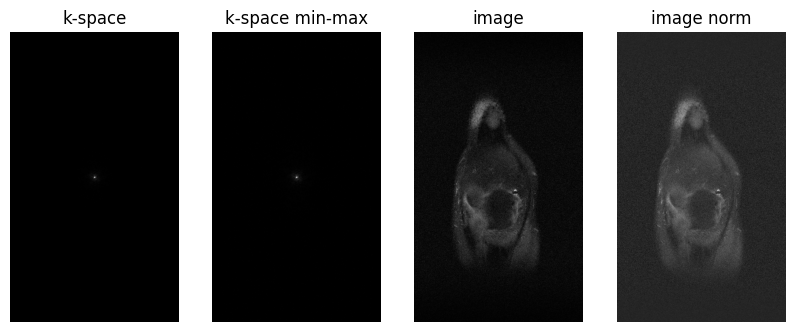

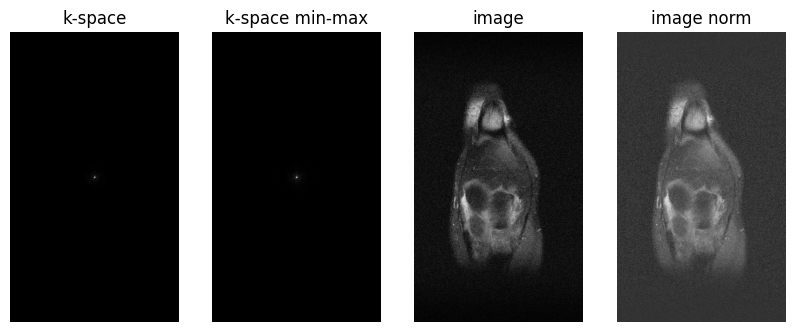

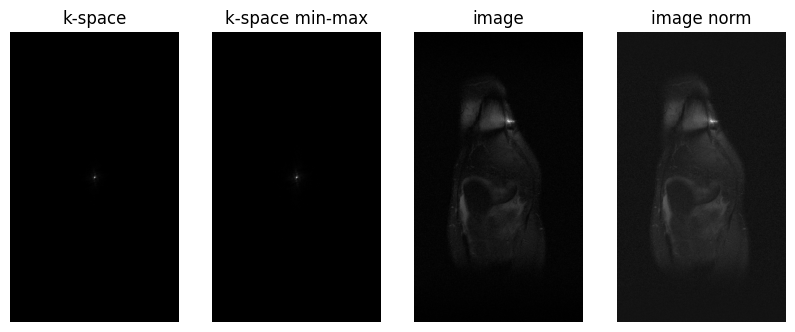

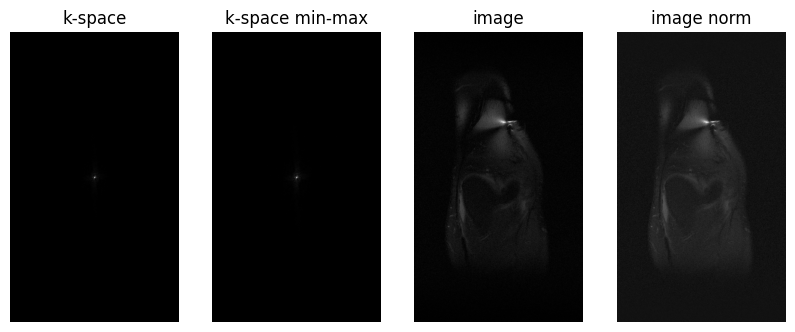

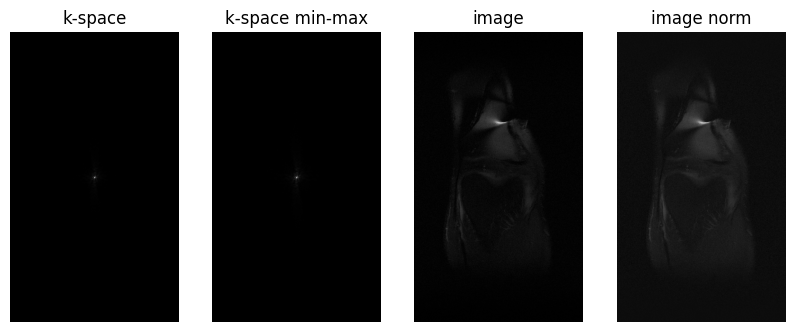

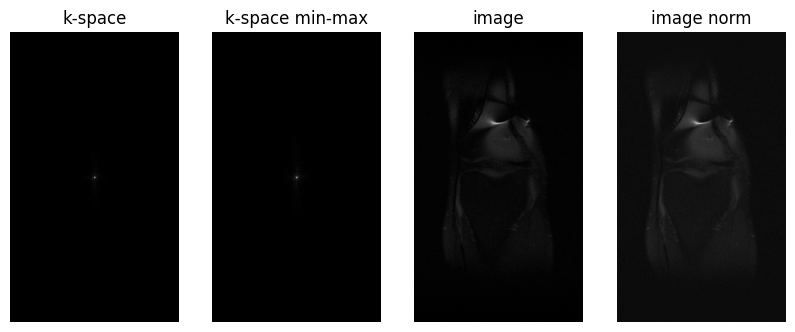

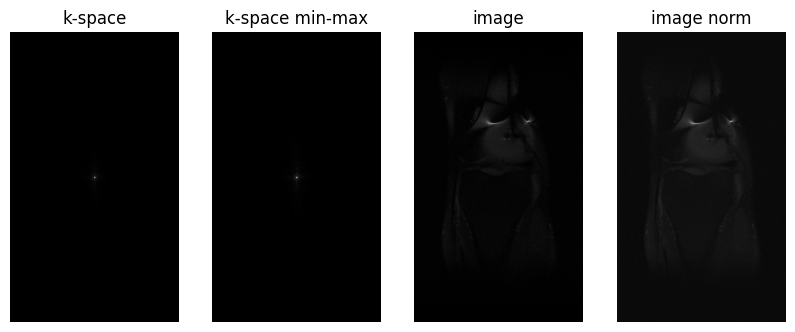

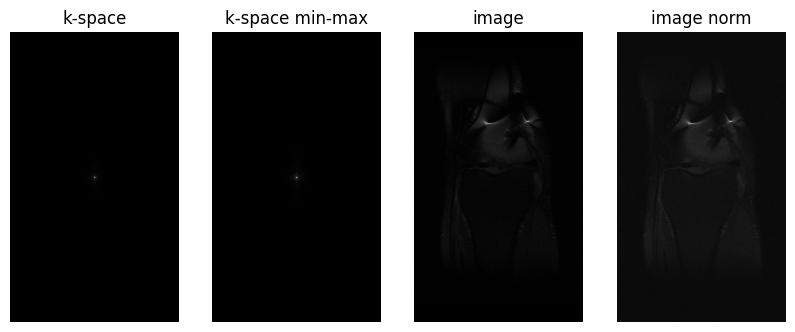

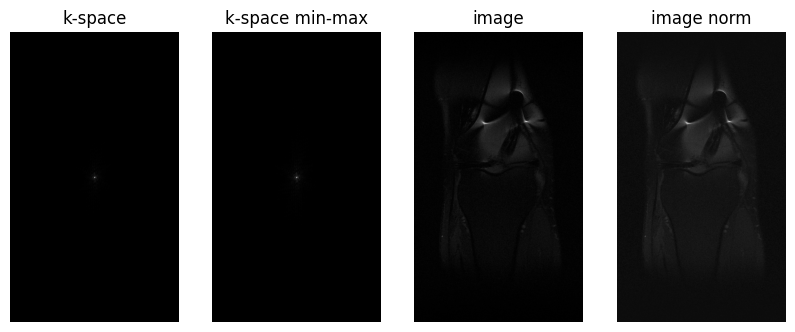

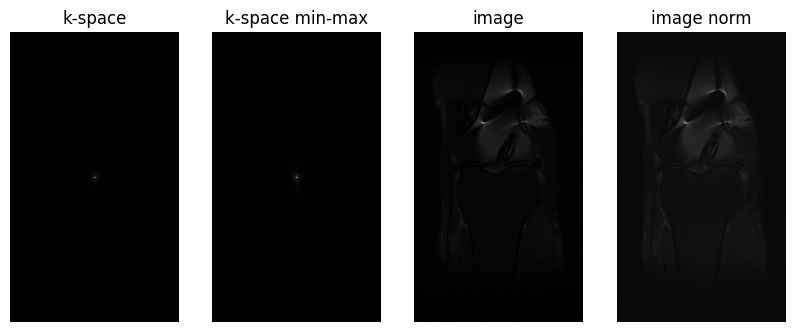

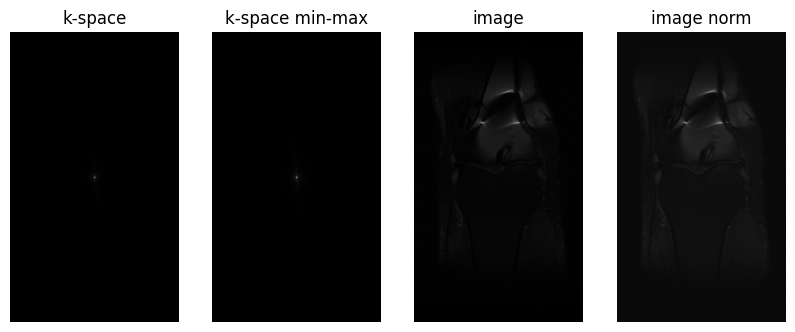

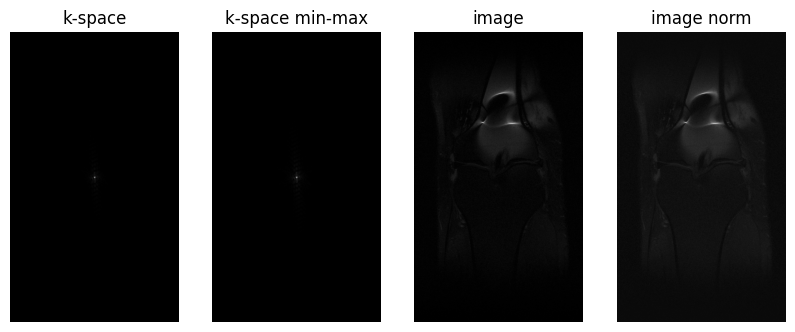

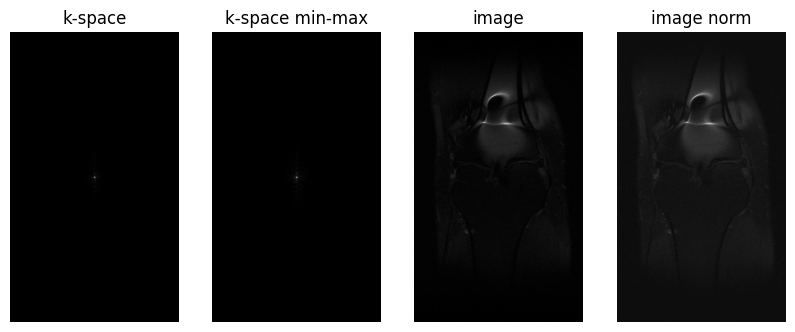

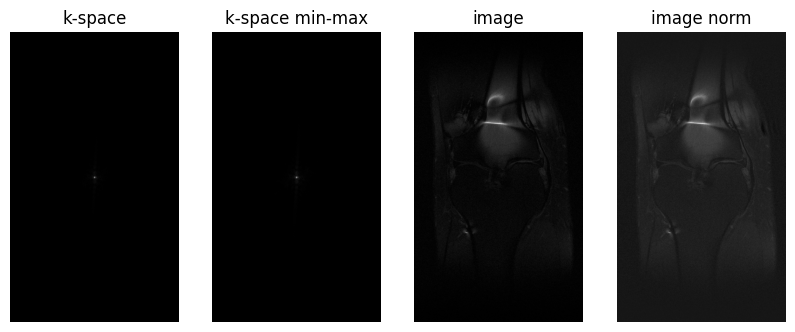

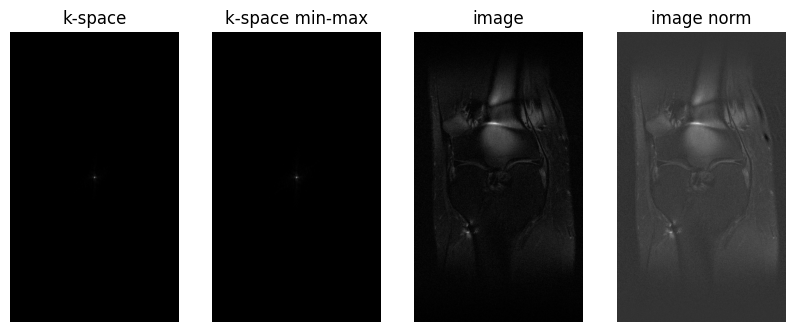

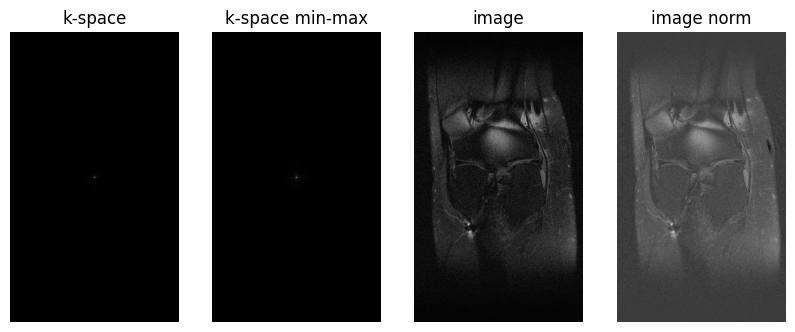

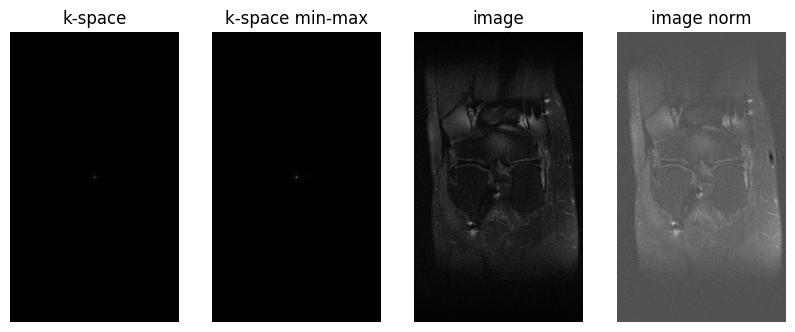

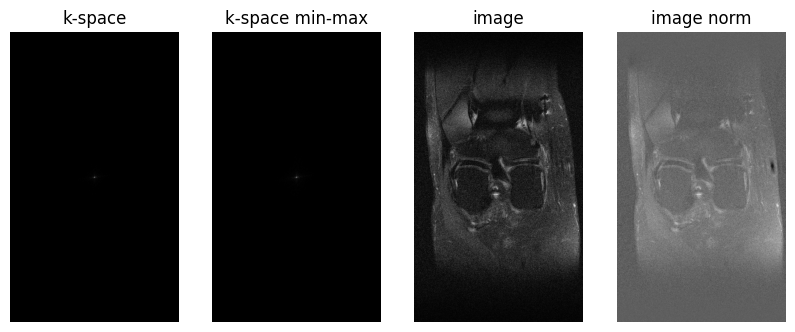

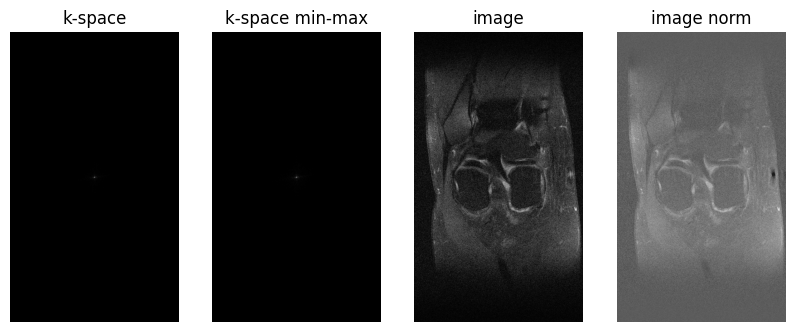

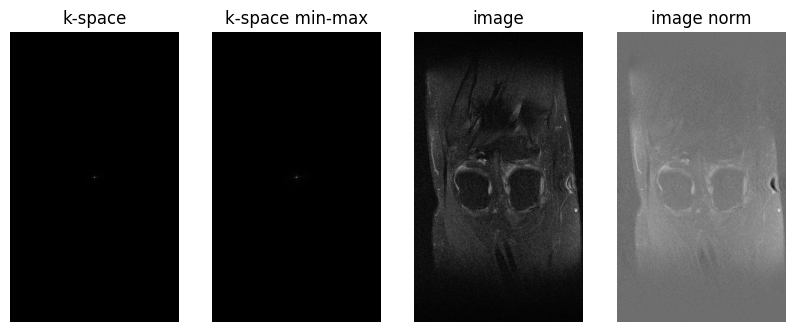

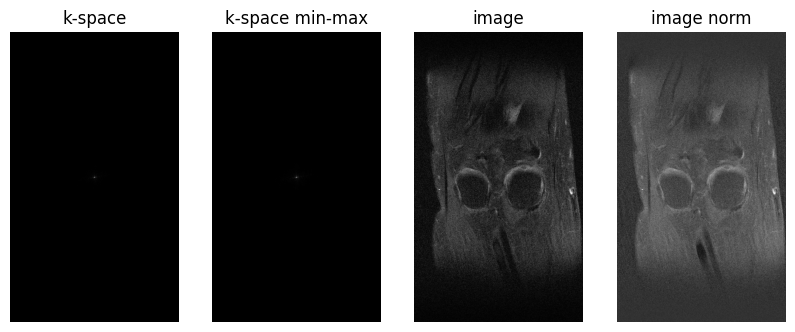

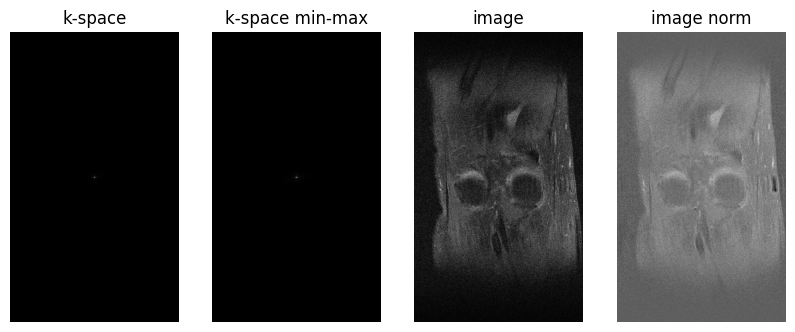

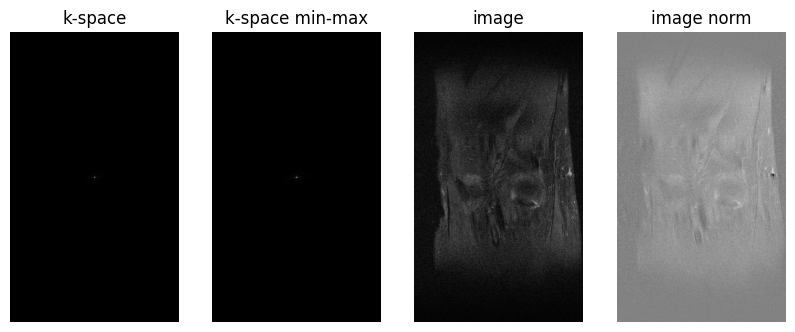

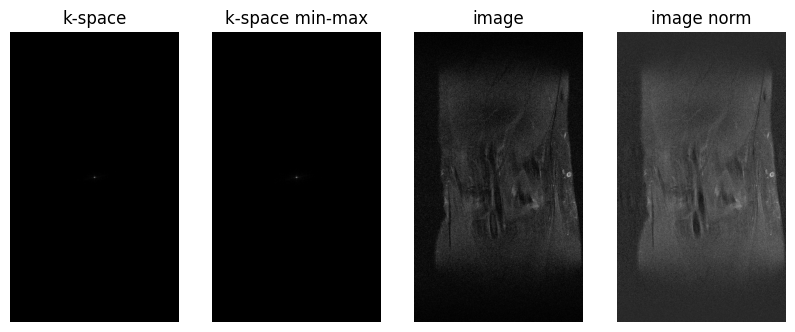

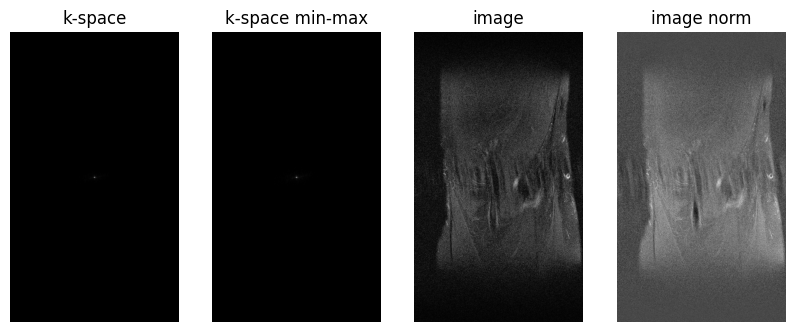

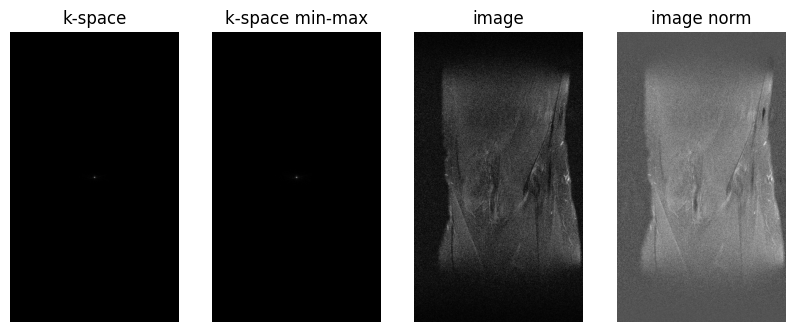

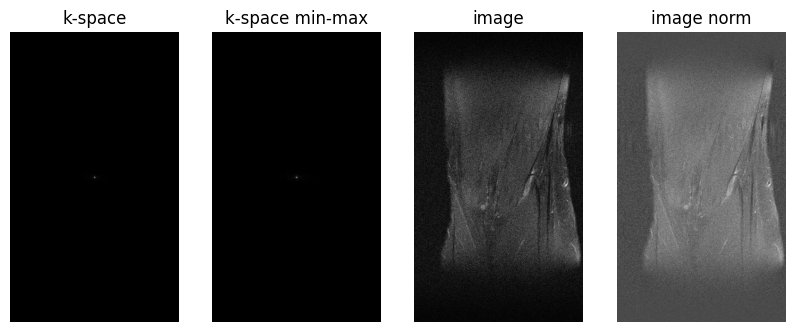

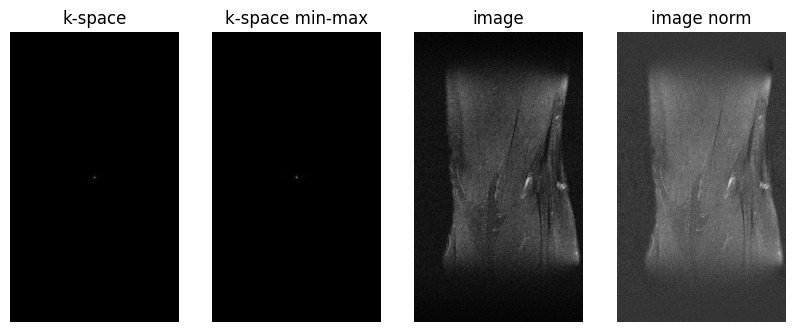

In [89]:
def minmax_norm(x):
    x = x - x.min()
    return x / (x.max() + 1e-9)

for ks in kspace:
    ks_sq = torch.tensor(ks.squeeze())
    img = ifft_2d(ks_sq)
    
    ks_min_max = minmax_norm(np.abs(ks_sq).numpy())
    img_min_max = minmax_norm(ifft_2d(ks_sq).numpy())
    
    fig, axes = plt.subplots(1, 4, figsize=(10, 5))
    
    axes[0].imshow(np.log1p(np.abs(ks_sq)), cmap="gray")
    axes[0].set_title("k-space")
    axes[0].axis("off")
    
    axes[1].imshow(np.log1p(ks_min_max), cmap="gray")
    axes[1].set_title("k-space min-max")
    axes[1].axis("off")
    
    axes[2].imshow(np.abs(img), cmap="gray")
    axes[2].set_title("image")
    axes[2].axis("off")
    
    axes[3].imshow(np.abs(img_min_max), cmap="gray")
    axes[3].set_title("image norm")
    axes[3].axis("off")

    plt.show()

In [55]:
torch.device("cpu")

device(type='cpu')

In [56]:
TARGET_H, TARGET_W = 320, 320
h, w = ks.shape
h0 = (h - TARGET_H) // 2
w0 = (w - TARGET_W) // 2
ks_sq = ks[h0:h0 + TARGET_H, w0:w0 + TARGET_W]  # (320, 320) center-cropped

mask = generate_column_mask((TARGET_H, TARGET_W), accel=8, device=torch.device("cpu"))
ks_tensor = torch.from_numpy(ks_sq).unsqueeze(0).unsqueeze(0)  # (1, 1, 320, 320)
kspace_input, kspaceDC_input, kspace_gt, kspace_metric = simulate_undersampling(ks_tensor, mask, learning="k_space")

print(f"ks_tensor shape : {ks_tensor.shape}")
print(f"mask shape      : {mask.shape}")


ks_tensor shape : torch.Size([1, 1, 320, 320])
mask shape      : torch.Size([320, 320])


/var/folders/5d/795fjfcd50n5hv5kddn8tqb80000gn/T/ipykernel_77308/164381142.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(norm(np.abs(kspace_input.squeeze())), cmap="gray")


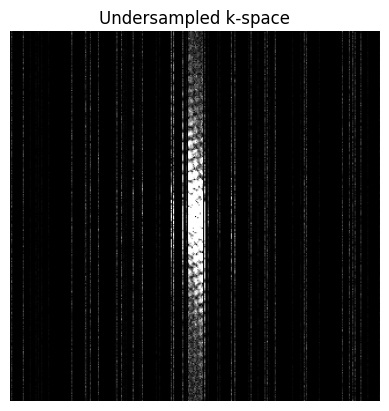

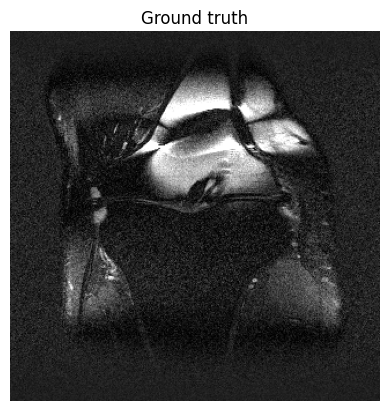

/var/folders/5d/795fjfcd50n5hv5kddn8tqb80000gn/T/ipykernel_77308/164381142.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(norm(np.abs(data_corrected_kspace.squeeze())), cmap="gray")


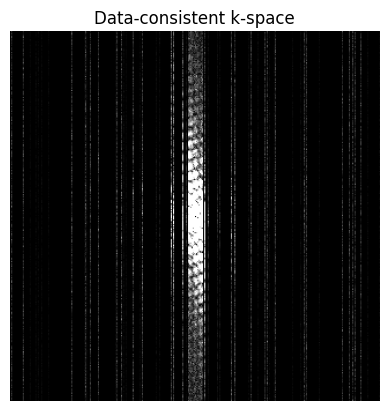

{'mean_r': tensor([[[[2.2067e-05]]]]), 'std_r': tensor([[[[3.0167e-05]]]]), 'mean_i': tensor([[[[-4.7585e-06]]]]), 'std_i': tensor([[[[2.1326e-05]]]])}
tensor(0.+0.j)
torch.ComplexFloatTensor


In [64]:
plt.imshow(norm(np.abs(kspace_input.squeeze())), cmap="gray")
plt.title("Undersampled k-space")
plt.axis("off")
plt.show()

plt.imshow(norm(kspace_gt.squeeze()), cmap="gray")
plt.title("Ground truth")
plt.axis("off")
plt.show()

data_corrected_kspace = KSpace_DC(kspace_input, kspaceDC_input, mask,1)
plt.imshow(norm(np.abs(data_corrected_kspace.squeeze())), cmap="gray")
plt.title("Data-consistent k-space")
plt.axis("off")
plt.show()

print(kspace_metric)
print(torch.sum(data_corrected_kspace - kspaceDC_input))
print(kspaceDC_input.type())


/var/folders/5d/795fjfcd50n5hv5kddn8tqb80000gn/T/ipykernel_77308/4096931672.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(norm(np.abs(im_input.squeeze())), cmap="gray")


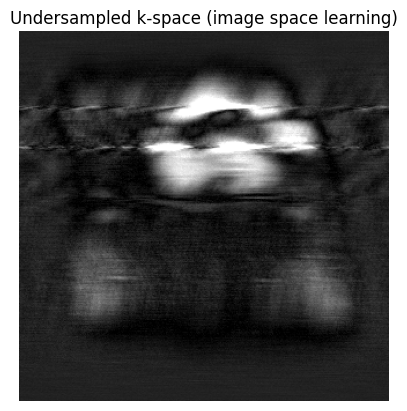

/var/folders/5d/795fjfcd50n5hv5kddn8tqb80000gn/T/ipykernel_77308/4096931672.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(norm(np.abs(im_gt.squeeze())), cmap="gray")


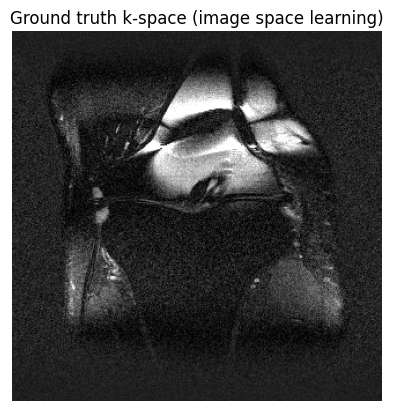

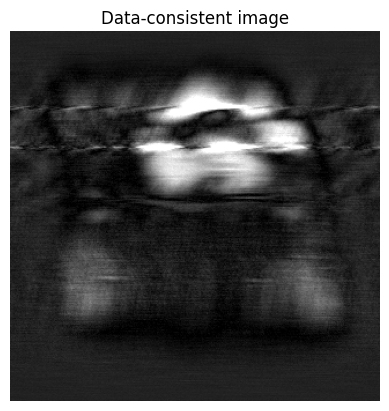

tensor(0.0002)


In [58]:
im_input, im_dc_input, im_gt, im_metric = simulate_undersampling(ks_tensor, mask, learning="image_space")

plt.imshow(norm(np.abs(im_input.squeeze())), cmap="gray")
plt.title("Undersampled k-space (image space learning)")
plt.axis("off")
plt.show()

plt.imshow(norm(np.abs(im_gt.squeeze())), cmap="gray")
plt.title("Ground truth k-space (image space learning)")
plt.axis("off")
plt.show()

data_corrected_image = FFT_DC(im_input, im_dc_input, mask,1)
plt.imshow(norm(data_corrected_image.squeeze()), cmap="gray")
plt.title("Data-consistent image")
plt.axis("off")
plt.show()

print(torch.sum(data_corrected_image - im_input))


In [ ]:
# PSNR: undersampled vs ground truth
# k-space mode: convert undersampled k-space back to magnitude image
ks_us_img = torch.abs(ifft_2d(kspace_input))   # [1,1,320,320] zero-filled recon magnitude
ks_psnr   = psnr(ks_us_img, kspace_gt)

# image mode: model_input is already the undersampled magnitude image
im_psnr = psnr(im_input, im_gt)

print(f"K-space mode  — PSNR (undersampled vs GT): {ks_psnr:.2f} dB")
print(f"Image mode    — PSNR (undersampled vs GT): {im_psnr:.2f} dB")


Input shape  : (1, 1, 320, 320)
fft2  output : (1, 1, 320, 320)
rfft2 output : (1, 1, 320, 161)


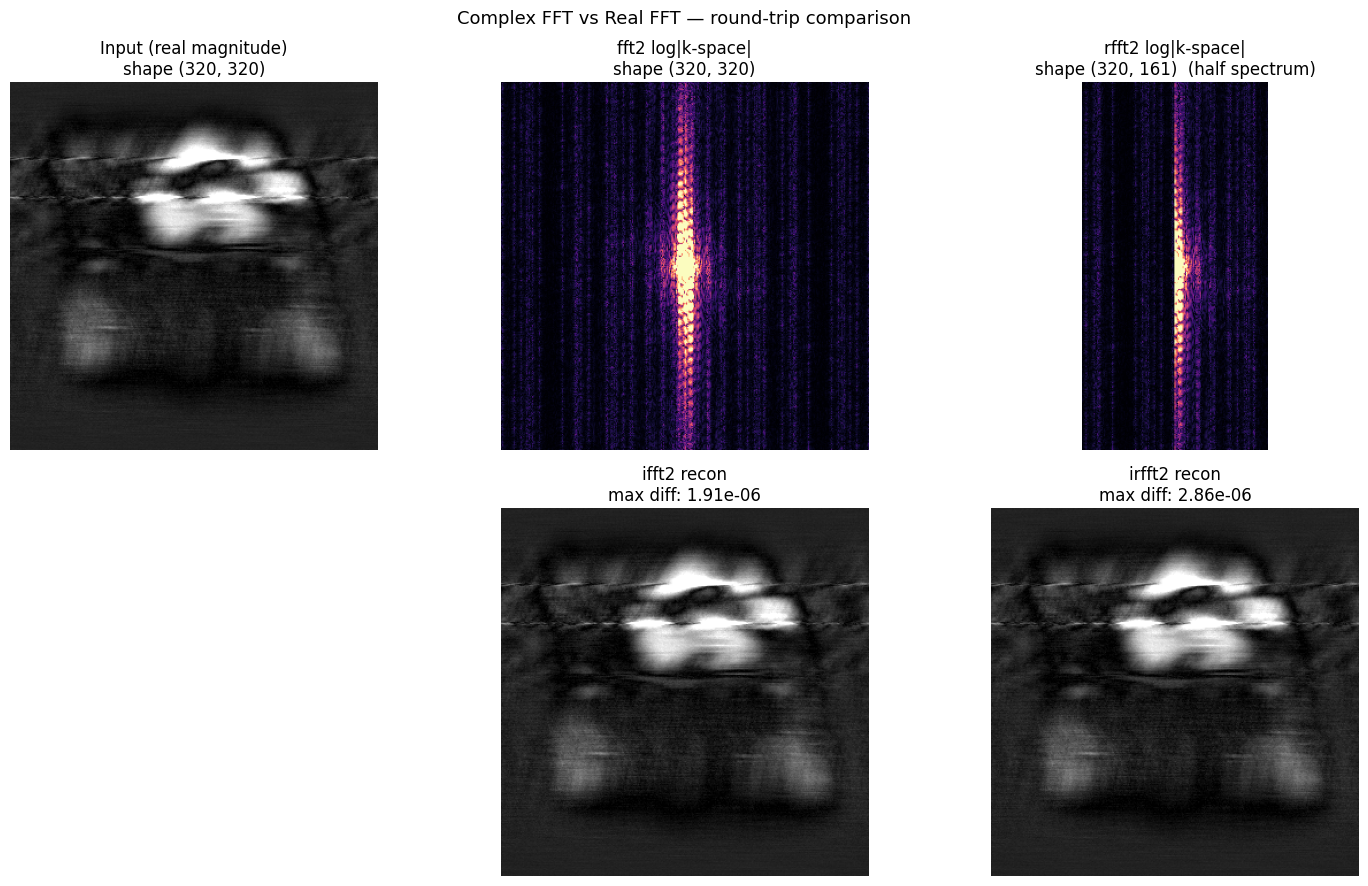

In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Use the real magnitude image from image-domain pipeline
real_img = im_input  # [1, 1, H, W] real tensor
H, W = real_img.shape[-2], real_img.shape[-1]

# Complex FFT (what we currently use)
ks_complex = torch.fft.fftshift(
    torch.fft.fft2(torch.fft.ifftshift(real_img, dim=(-2,-1)), norm='ortho', dim=(-2,-1)),
    dim=(-2,-1)
)  # [1, 1, H, W] complex — full spectrum

# Real FFT
ks_real = torch.fft.fftshift(
    torch.fft.rfft2(torch.fft.ifftshift(real_img, dim=(-2,-1)), norm='ortho', dim=(-2,-1)),
    dim=(-2,-1)
)  # [1, 1, H, W//2+1] complex — half spectrum

print(f"Input shape  : {tuple(real_img.shape)}")
print(f"fft2  output : {tuple(ks_complex.shape)}")
print(f"rfft2 output : {tuple(ks_real.shape)}")

# Reconstruct back
recon_complex = torch.abs(torch.fft.fftshift(
    torch.fft.ifft2(torch.fft.ifftshift(ks_complex, dim=(-2,-1)), norm='ortho'),
    dim=(-2,-1)
)).squeeze()

recon_real = torch.fft.fftshift(
    torch.fft.irfft2(torch.fft.ifftshift(ks_real, dim=(-2,-1)), norm='ortho', s=(H, W)),
    dim=(-2,-1)
).squeeze()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0,0].imshow(norm(real_img.squeeze().numpy()), cmap='gray')
axes[0,0].set_title(f"Input (real magnitude)\nshape {(H, W)}")

axes[0,1].imshow(norm(np.log1p(ks_complex.abs().squeeze().numpy())), cmap='magma')
axes[0,1].set_title(f"fft2 log|k-space|\nshape {tuple(ks_complex.shape[-2:])}")

axes[0,2].imshow(norm(np.log1p(ks_real.abs().squeeze().numpy())), cmap='magma')
axes[0,2].set_title(f"rfft2 log|k-space|\nshape {tuple(ks_real.shape[-2:])}  (half spectrum)")

axes[1,0].set_visible(False)

axes[1,1].imshow(norm(recon_complex.numpy()), cmap='gray')
axes[1,1].set_title(f"ifft2 recon\nmax diff: {(recon_complex - real_img.squeeze()).abs().max():.2e}")

axes[1,2].imshow(norm(recon_real.numpy()), cmap='gray')
axes[1,2].set_title(f"irfft2 recon\nmax diff: {(recon_real - real_img.squeeze()).abs().max():.2e}")

for ax in axes.flat:
    ax.axis('off')

plt.suptitle("Complex FFT vs Real FFT — round-trip comparison", fontsize=13)
plt.tight_layout()
plt.show()


In [60]:
h, w = ks.shape  # 640, 372
center_h, center_w = h // 2, w // 2
ks_cropped = ks[center_h - 160 : center_h + 160, center_w - 160 : center_w + 160]

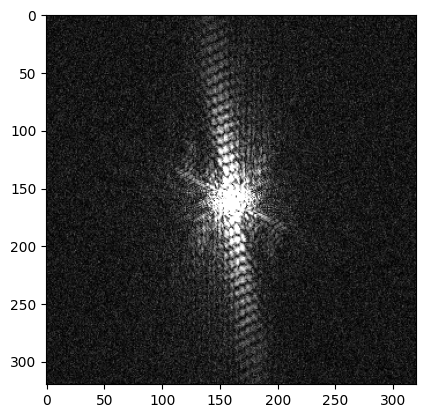

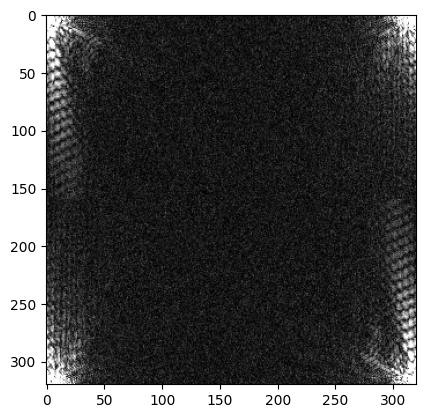

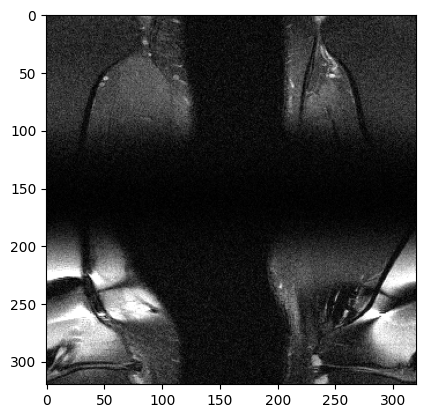

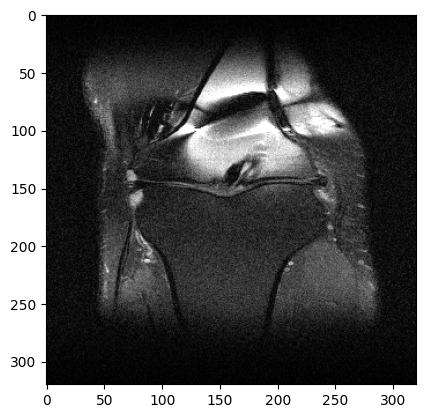

In [61]:
Raw = ks_cropped
shifted = np.fft.ifftshift(Raw)
ifft = np.fft.ifft2(shifted)
image = np.fft.fftshift(ifft)

plt.imshow(norm(np.log1p(np.abs(Raw))), cmap="gray")
plt.show()

plt.imshow(norm(np.log1p(np.abs(shifted))), cmap="gray")
plt.show()

plt.imshow(norm(np.log1p(np.abs(ifft))), cmap="gray")
plt.show()

plt.imshow(norm(np.log1p(np.abs(image))), cmap="gray")  
plt.show()


attrs['max']  = 0.0009
attrs['norm'] = 0.0597


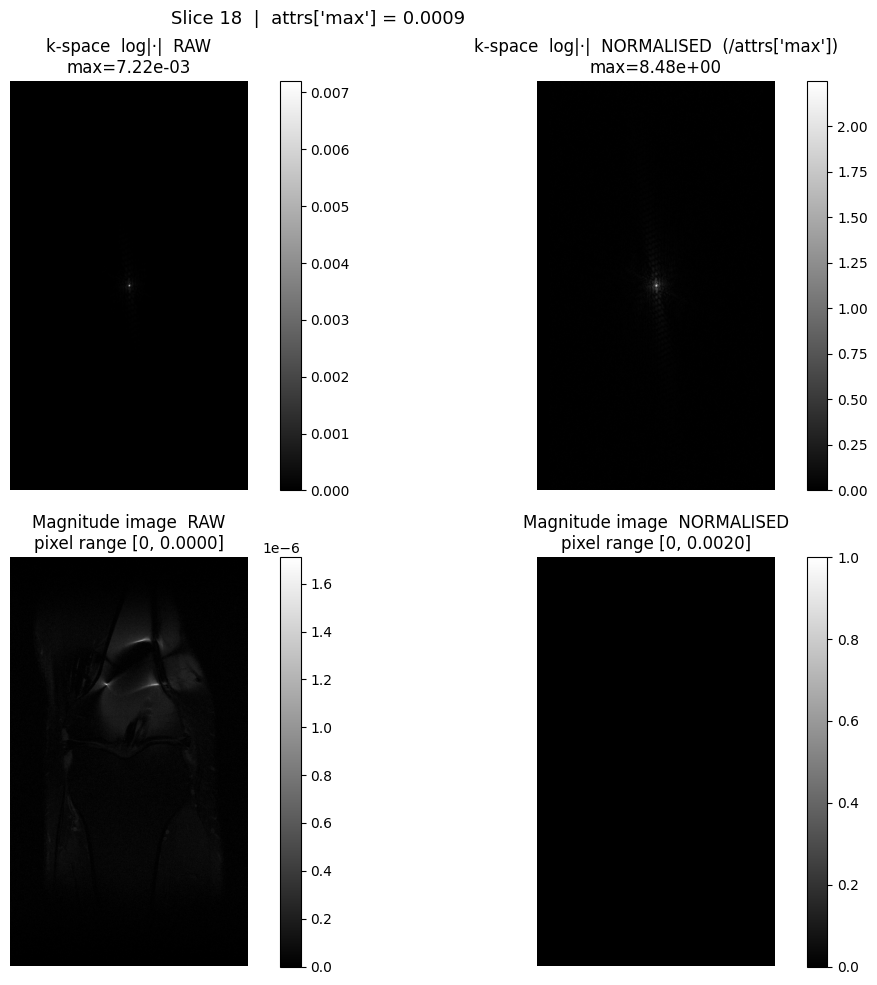

In [62]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

FILE = "../file1000001.h5"

with h5py.File(FILE, "r") as f:
    kspace = f["kspace"][:]
    rss    = f["reconstruction_rss"][:]
    max_val  = f.attrs["max"]   # fastMRI normalisation scalar
    norm_val = f.attrs["norm"]  # k-space norm (less commonly used)

print(f"attrs['max']  = {max_val:.4f}")
print(f"attrs['norm'] = {norm_val:.4f}")

sl = kspace.shape[0] // 2
ks = kspace[sl]          # (640, 372) complex64

# ── reconstructions ──────────────────────────────────────────────────────────
naive_img      = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(ks))))
naive_img_norm = naive_img / max_val

ks_norm        = ks / max_val

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# row 0 — k-space log magnitude
im00 = axes[0, 0].imshow(np.log1p(np.abs(ks)),      cmap="gray")
im01 = axes[0, 1].imshow(np.log1p(np.abs(ks_norm)), cmap="gray")
axes[0, 0].set_title(f"k-space  log|·|  RAW\nmax={np.abs(ks).max():.2e}")
axes[0, 1].set_title(f"k-space  log|·|  NORMALISED  (/attrs['max'])\nmax={np.abs(ks_norm).max():.2e}")
plt.colorbar(im00, ax=axes[0, 0])
plt.colorbar(im01, ax=axes[0, 1])

# row 1 — magnitude image
im10 = axes[1, 0].imshow(naive_img,      cmap="gray", vmin=0, vmax=naive_img.max())
im11 = axes[1, 1].imshow(naive_img_norm, cmap="gray", vmin=0, vmax=1.0)
axes[1, 0].set_title(f"Magnitude image  RAW\npixel range [0, {naive_img.max():.4f}]")
axes[1, 1].set_title(f"Magnitude image  NORMALISED\npixel range [0, {naive_img_norm.max():.4f}]")
plt.colorbar(im10, ax=axes[1, 0])
plt.colorbar(im11, ax=axes[1, 1])

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(f"Slice {sl}  |  attrs['max'] = {max_val:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

In [63]:
with h5py.File(FILE, "r") as f:
    print("=== datasets ===")
    for key in f.keys():
        obj = f[key]
        print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")

    print("\n=== attributes ===")
    for key, val in f.attrs.items():
        print(f"  {key}: {val}")

=== datasets ===
  ismrmrd_header: shape=(), dtype=object
  kspace: shape=(36, 640, 372), dtype=complex64
  reconstruction_esc: shape=(36, 320, 320), dtype=float32
  reconstruction_rss: shape=(36, 320, 320), dtype=float32

=== attributes ===
  acquisition: CORPDFS_FBK
  max: 0.000851878253624366
  norm: 0.0596983310320022
  patient_id: 0beb8905d9b7fad304389b9d4263c57d5b069257ea0fdc5bf7f2675608a47406
